#Q1. Supervised Learning

In [3]:
import pandas as pd
import numpy as np

# visualization. libraries
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# evaluation
from sklearn.metrics import confusion_matrix, classification_report

# hyperparameter tuning
from sklearn.model_selection import GridSearchCV


pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

##1. Data Loading and Inspection

In [11]:
df = pd.read_csv("/q1_heart_disease.csv")

# shape
print("Shape:", df.shape)

# data types
print("\nData Types:")
print(df.dtypes)

print("\n")

# missing values
print("\nMissing Values:")
print(df.isnull().sum())

print("\n")

# first 5 rows
df.head()

Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object



Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64




,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. Exploratory Data Analysis

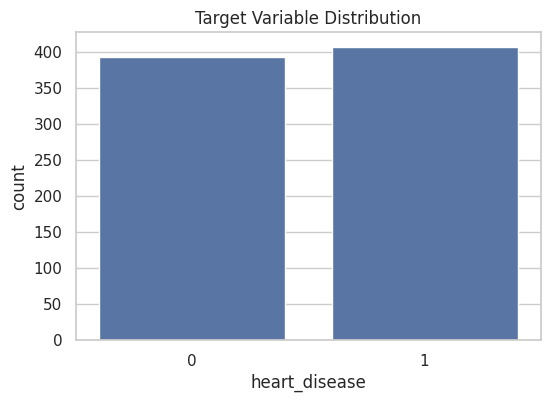

In [13]:
# target class distribution plot

plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease', data=df)
plt.title("Target Variable Distribution")
plt.show()

#### Interpretation:
The dataset appears to be balanced with almost equal counts of patients with(1) and without(0) heart disease. There is a minimal difference. This is beneficial for model training because it reduces bias towards any particular class. Models trained on balanced data are more likely to generalize well and produce reliable predictions.

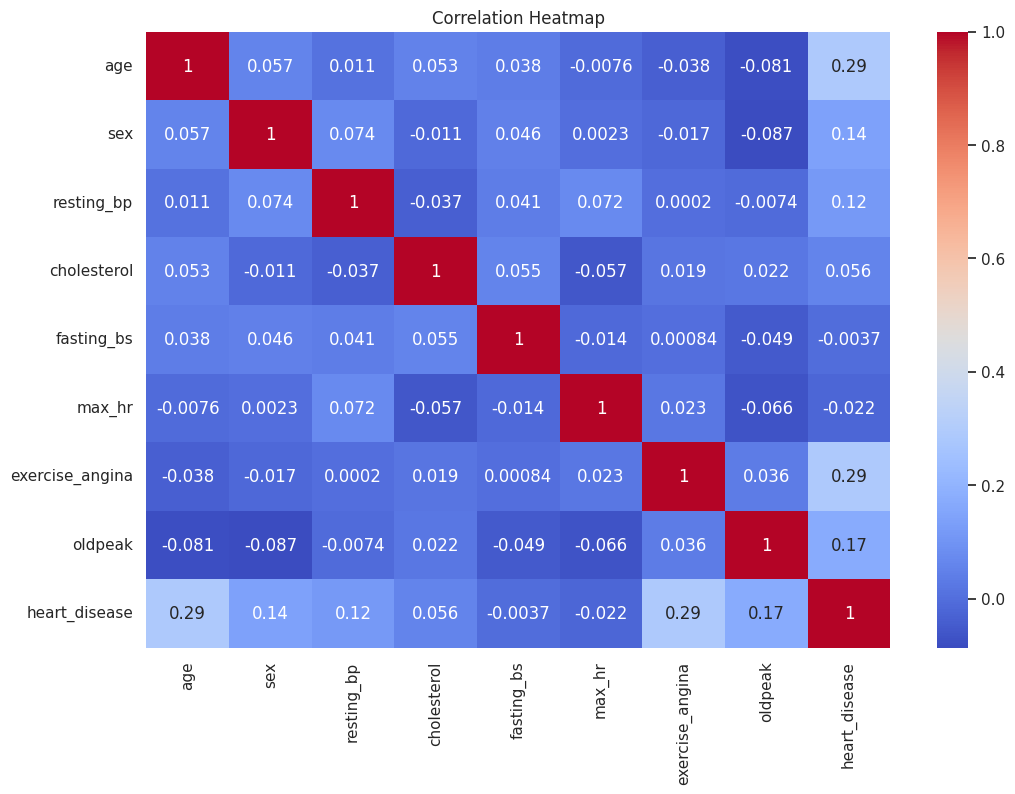

In [17]:
# correlation heatmap


plt.figure(figsize=(12,8))

# select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()



#### Interpretation:

The features age and exercise_angina have the highest positive correlation(0.29) with heart disease, indicating they are important predictors. oldpeak feature shows a moderate positive correlation(0.17) with heart_disease.
The other features mostly have weak correlations,indicating that heart disease prediction depends on a combination of multiple factors rather than a single strong predictor.
Features like age,exercise_angina,sex,oldpeak may influence heart disease prediction.
There is no strong multicollinearity observed among features, which is beneficial for model performance.

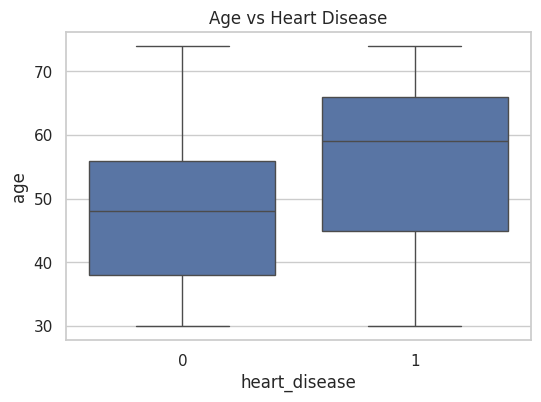

In [18]:
# feature vs target boxplot

plt.figure(figsize=(6,4))
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

#### Interpretation:

The boxplot shows that patients with heart disease(1) tend to have a higher median age compared to those without heart disease(0).
The spread of age values is wider for patients with heart disease, showing that age is an important factor influencing the chances of having a heart disease.
From this plot, we can see that older individuals are at a higher risk.

##3. Data Preprocessing

#### Data Preprocessing

Missing values are handled using sing median imputation for numerical features, as it is robust to outliers and preserves the distribution of the data.


In [19]:
# separate features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

In [20]:
# handle missing values with median
X = X.fillna(X.median(numeric_only=True))

In [21]:
# one hot encooding - convert categorical variables
X = pd.get_dummies(X, drop_first=True)

In [22]:
# feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
# train-test splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

##4. Model Training

In [24]:
# initializing models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# train models
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

##5. Model Evaluation

In [36]:
def evaluate_model(model, name):
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("-"*30)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("="*60)

In [37]:
# evaluate models
evaluate_model(dt, "Decision Tree")
evaluate_model(rf, "Random Forest")
evaluate_model(gb, "Gradient Boosting")


Decision Tree
------------------------------
Confusion Matrix:
[[56 23]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


Random Forest
------------------------------
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
------------------------------
Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precisi

#### Model Comparison

The best performing model is Random Forest because -

- It has higher accuracy(0.79) than gradient boosting(0.77) and decision tree(0.70).
- It has the highest F1-score among all models
- It balances precision and recall effectively
- It reduces overfitting by combining multiple decision trees

So, Random Forest is selected is the best model.

##6. Hyperparameter Tuning

In [27]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [28]:
best_model = grid.best_estimator_

evaluate_model(best_model, "Tuned Random Forest")


Tuned Random Forest
Confusion Matrix:
[[59 20]
 [17 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        79
           1       0.76      0.79      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



#### Hyperparameter Tuning Results

The best parameters found were:

- n_estimators = 200
- max_depth = none
- min_samples_split = 2

After tuning,

- the model performance slightly decreased compared to the random forest baseline model.
- F1-score reduced from approximately 0.79–0.80 to around 0.77.

This indicates that the default model was already working well for this dataset and hyperparameter tuning did not improve performance much. So, hyperparameter tuning had minimal effect in this case.